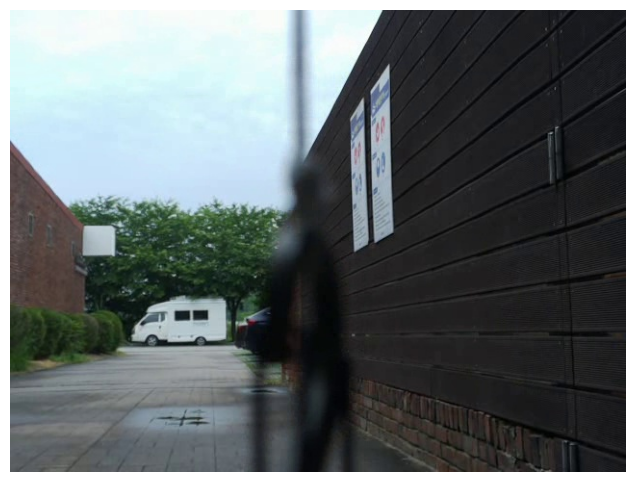

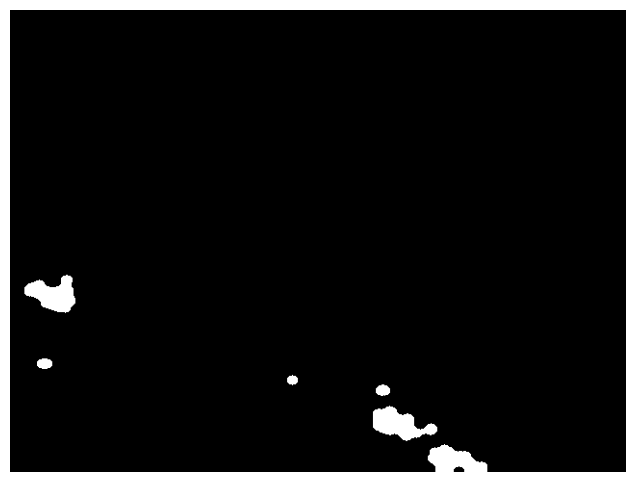

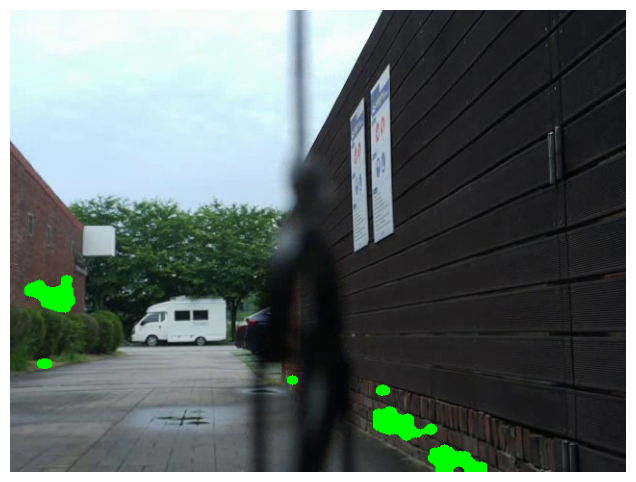

0.0040234375


In [16]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

IMG_FOLDER = Path("../data/extracted_frames/may25/may25_strike_bell")
IMG_FOLDER2 = Path("../data/extracted_frames/may26/may26_bell_moving_indoors")

IMG_PATH = IMG_FOLDER / "frame_000600.jpg"
img1 = IMG_FOLDER / "frame_000600.jpg"
img2 = IMG_FOLDER / "frame_000750.jpg"
img3 = IMG_FOLDER / "frame_001470.jpg"
img4 = IMG_FOLDER2 / "frame_000380.jpg"
img5 = IMG_FOLDER2 / "frame_000440.jpg"

def show(img, title="", cmap=None, size=(8, 6)):
    plt.figure(figsize=size)
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap or "gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

img = cv2.imread(img5)
# gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# show(img)
blur = cv2.GaussianBlur(img, (5, 5), 0)
hsv = cv2.cvtColor(blur, cv2.COLOR_BGR2HSV)

# Warm/gold/brown/yellow regions
gold_mask = cv2.inRange(
    hsv,
    np.array([8, 35, 40]),
    np.array([35, 255, 255])
)

# Bright low-saturation reflections
bright_mask = cv2.inRange(
    hsv,
    np.array([0, 0, 180]),
    np.array([180, 90, 255])
)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
gold_nearby = cv2.dilate(gold_mask, kernel, iterations=2)

valid_bright = cv2.bitwise_and(bright_mask, gold_nearby)
mask = cv2.bitwise_or(gold_mask, valid_bright)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

show(img)
show(mask)

contours, _ = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)
# contours_gray, _ = cv2.findContours(
#     gray,
#     cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
# )
cv2.drawContours(img, contours, -1, (0, 255, 0), -1)
show(img)
# largest_gray = max(contours_gray, key=cv2.contourArea)
largest = max(contours, key=cv2.contourArea)
area = cv2.contourArea(largest)
roi_area = img.shape[0] * img.shape[1]
area_ratio = area / roi_area
print(area_ratio)

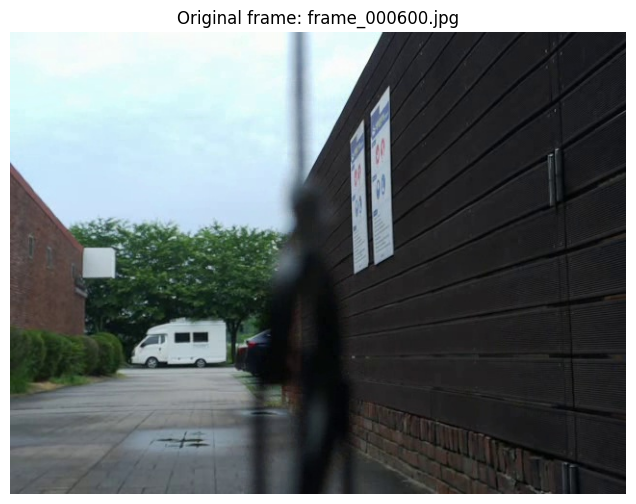

(480, 640, 3)


In [18]:
frame = cv2.imread(str(img5))

if frame is None:
    raise FileNotFoundError(f"Could not read image: {IMG_PATH}")

show(frame, f"Original frame: {IMG_PATH.name}")
print(frame.shape)


In [19]:
hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

# broad yellow / gold / brown-ish range
gold_mask = cv2.inRange(
    hsv,
    np.array([10, 40, 40]),
    np.array([45, 255, 255])
)

# shiny highlights: bright low-saturation or bright pixels
bright_mask = cv2.inRange(
    hsv,
    np.array([0, 0, 190]),
    np.array([180, 90, 255])
)

bell_mask = cv2.bitwise_or(gold_mask, bright_mask)

In [20]:
kernel = np.ones((5, 5), np.uint8)
bell_mask = cv2.morphologyEx(bell_mask, cv2.MORPH_OPEN, kernel)
bell_mask = cv2.morphologyEx(bell_mask, cv2.MORPH_CLOSE, kernel)

In [21]:
coverage = np.count_nonzero(bell_mask) / bell_mask.size

In [22]:
if coverage > 0.5:
    # stop_climbing()
    print("found")

In [23]:
# def bell_close_trigger(frame):
#     h, w = frame.shape[:2]

#     # Only check strike region
#     x1 = int(0.20 * w)
#     x2 = int(0.80 * w)
#     y1 = int(0.15 * h)
#     y2 = int(0.90 * h)
#     roi = frame[y1:y2, x1:x2]

#     hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

#     # Broad gold/brown/yellow range
#     gold = cv2.inRange(
#         hsv,
#         np.array([8, 35, 40]),
#         np.array([45, 255, 255])
#     )

#     # Shiny reflections on metal
#     bright = cv2.inRange(
#         hsv,
#         np.array([0, 0, 180]),
#         np.array([180, 90, 255])
#     )

#     # Avoid pure sky/white dominating too much by requiring nearby warm/gold
#     gold_dilated = cv2.dilate(
#         gold,
#         cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (31, 31)),
#         iterations=1
#     )
#     bright_near_gold = cv2.bitwise_and(bright, gold_dilated)

#     mask = cv2.bitwise_or(gold, bright_near_gold)

#     kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
#     mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
#     mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

#     coverage = cv2.countNonZero(mask) / mask.size

#     num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
#     largest = 0
#     for i in range(1, num_labels):
#         largest = max(largest, stats[i, cv2.CC_STAT_AREA])

#     largest_ratio = largest / mask.size

#     return coverage, largest_ratio, mask



import cv2
import numpy as np


def bell_close_trigger(frame, color_format="bgr"):
    """
    Returns:
        result: dict with detection scores
        debug: dict with roi/masks for visualization
    """

    h, w = frame.shape[:2]

    # Only check strike region
    x1 = int(0.20 * w)
    x2 = int(0.80 * w)
    y1 = int(0.15 * h)
    y2 = int(0.90 * h)

    roi = frame[y1:y2, x1:x2]

    if color_format == "rgb":
        roi_bgr = cv2.cvtColor(roi, cv2.COLOR_RGB2BGR)
    else:
        roi_bgr = roi

    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB)

    # --------------------------------------------------
    # 1. Broad possible bell mask
    # --------------------------------------------------

    # Broad gold/brown/yellow range
    gold = cv2.inRange(
        hsv,
        np.array([8, 35, 40]),
        np.array([45, 255, 255])
    )

    # Shiny reflections on metal
    bright = cv2.inRange(
        hsv,
        np.array([0, 0, 180]),
        np.array([180, 90, 255])
    )

    # Only accept bright highlights if they are near gold-ish pixels
    gold_dilated = cv2.dilate(
        gold,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (31, 31)),
        iterations=1
    )

    bright_near_gold = cv2.bitwise_and(bright, gold_dilated)

    broad_mask = cv2.bitwise_or(gold, bright_near_gold)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    broad_mask = cv2.morphologyEx(broad_mask, cv2.MORPH_OPEN, kernel)
    broad_mask = cv2.morphologyEx(broad_mask, cv2.MORPH_CLOSE, kernel)

    # --------------------------------------------------
    # 2. Strict brass seed mask
    # Similar idea to Codex code's brass_ratio
    # --------------------------------------------------

    brass_hsv = cv2.inRange(
        hsv,
        np.array([8, 45, 50]),
        np.array([34, 255, 255])
    )

    brass_lab = cv2.inRange(
        lab,
        np.array([35, 102, 132]),
        np.array([255, 155, 195])
    )

    brass_seed = cv2.bitwise_and(brass_hsv, brass_lab)

    # Optional red/warm dominance like Codex code
    b, g, r = cv2.split(roi_bgr.astype(np.float32))
    red_dominant = np.uint8((r > g) & (r > b * 1.15)) * 255
    brass_seed = cv2.bitwise_and(brass_seed, red_dominant)

    brass_seed = cv2.morphologyEx(
        brass_seed,
        cv2.MORPH_OPEN,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    )

    # --------------------------------------------------
    # 3. Connected components on broad mask
    # --------------------------------------------------

    coverage = cv2.countNonZero(broad_mask) / broad_mask.size

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(broad_mask)

    largest_label = None
    largest_area = 0

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area > largest_area:
            largest_area = area
            largest_label = i

    if largest_label is None or largest_area == 0:
        result = {
            "detected": False,
            "coverage": coverage,
            "largest_ratio": 0.0,
            "brass_ratio": 0.0,
            "score": 0.0,
            "box": None,
            "center": None,
        }

        debug = {
            "roi": roi,
            "broad_mask": broad_mask,
            "brass_seed": brass_seed,
        }

        return result, debug

    component_mask = np.uint8(labels == largest_label) * 255

    x, y, bw, bh, area = stats[largest_label]
    cx, cy = centroids[largest_label]

    largest_ratio = largest_area / broad_mask.size

    # --------------------------------------------------
    # 4. brass_ratio calculation
    # --------------------------------------------------

    brass_pixels = cv2.countNonZero(
        cv2.bitwise_and(brass_seed, component_mask)
    )

    brass_ratio = brass_pixels / float(largest_area)

    # --------------------------------------------------
    # 5. Final trigger decision
    # --------------------------------------------------

    detected = (
        coverage > 0.12 and
        largest_ratio > 0.08 and
        brass_ratio > 0.25
    )

    # Optional combined score for logging
    score = (
        0.45 * min(1.0, coverage / 0.30) +
        0.35 * min(1.0, largest_ratio / 0.20) +
        0.20 * min(1.0, brass_ratio / 0.50)
    )

    result = {
        "detected": detected,
        "coverage": float(coverage),
        "largest_ratio": float(largest_ratio),
        "brass_ratio": float(brass_ratio),
        "score": float(score),
        "box": (int(x + x1), int(y + y1), int(bw), int(bh)),  # full-frame coords
        "center": (float(cx + x1), float(cy + y1)),          # full-frame coords
    }

    debug = {
        "roi": roi,
        "broad_mask": broad_mask,
        "brass_seed": brass_seed,
        "component_mask": component_mask,
    }

    return result, debug

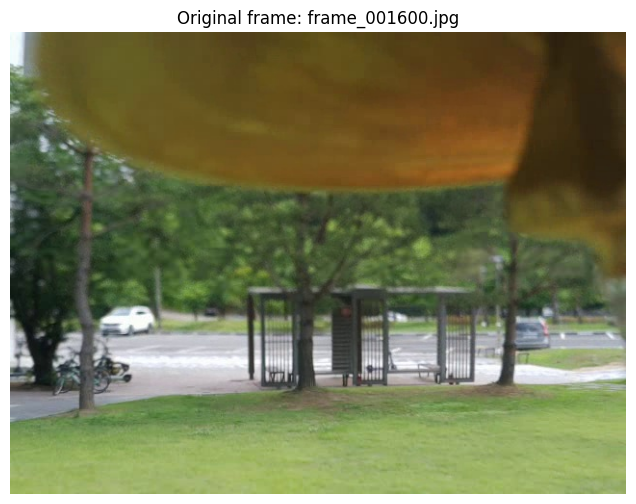

(480, 640, 3)


In [46]:
IMG_FOLDER = Path("../data/extracted_frames/may25/may25_strike_bell")
IMG_PATH = IMG_FOLDER / "frame_001600.jpg"
frame = cv2.imread(str(IMG_PATH))

if frame is None:
    raise FileNotFoundError(f"Could not read image: {IMG_PATH}")

show(frame, f"Original frame: {IMG_PATH.name}")
print(frame.shape)


In [48]:
result, debug = bell_close_trigger(frame)
# show(mask)
print(result["detected"])
print(result)

True
{'detected': True, 'coverage': 0.645775462962963, 'largest_ratio': 0.45925202546296295, 'brass_ratio': 0.5298407548001953, 'score': 1.0, 'box': (128, 72, 384, 256), 'center': (330.649786570479, 169.10706128813774)}
